In [6]:
import pandas as pd
import numpy as np
from statsmodels.tsa.ar_model import AutoReg
import json

In [7]:
with open('params.json') as f:
    p = json.load(f)

data_quarterly = pd.read_excel("..//data/DataParametrization.xlsx", sheet_name="Quarterly")
for col in ['tot', 'px', 'pm', 'X', 'M', 'Y']:
    data_quarterly[col] = pd.to_numeric(data_quarterly[col], errors='coerce')

gamma (import share): 0.2443
gamma (avg trade share): 0.2594


<Axes: >

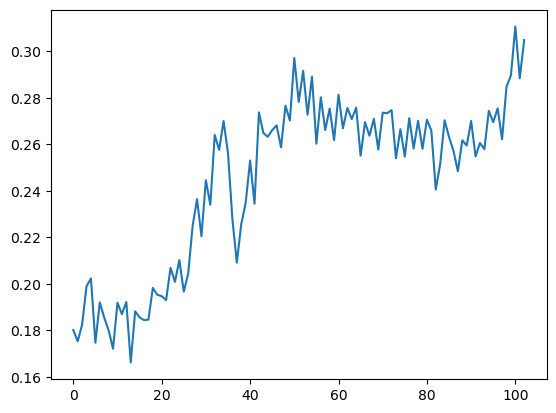

In [8]:
gamma_xm    = ((data_quarterly.X + data_quarterly.M)/(2*data_quarterly.Y)).mean() # Openness measure
gamma_m     = (data_quarterly.M/data_quarterly.Y).mean() # Consumption on tradables share
p["gamma"]  = round(gamma_m, 4)

print(f'gamma (import share): {gamma_m:.4f}')
print(f'gamma (avg trade share): {gamma_xm:.4f}')

(data_quarterly.M/data_quarterly.Y).plot.line()

In [9]:
tot        = np.log(data_quarterly.tot.astype(float)).dropna()
tot_demean = tot - tot.mean()

ar_q = AutoReg(tot_demean, lags=1).fit()
rho_q = ar_q.params.iloc[1]
sigma_q = np.std(ar_q.resid)

print(f'rho_q = {rho_q:.4f}')
print(f'sigma_q = {sigma_q:.6f}')

p['rho_q'] = round(float(rho_q), 4)
p['sigma_q'] = round(float(sigma_q), 6)

rho_q = 0.9904
sigma_q = 0.041422


In [10]:
#####################
# Update params.json
#####################

with open('params.json', 'w') as f:
    json.dump(p, f, indent=4)